# Keras Syntax Basics

With TensorFlow 2.0 , Keras is now the main API choice. Let's work through a simple regression project to understand the basics of the Keras syntax and adding layers.

## The Data

To learn the basic syntax of Keras, we will use a very simple fake data set, in the subsequent lectures we will focus on real datasets, along with feature engineering! For now, let's focus on the syntax of TensorFlow 2.0.

Let's pretend this data are measurements of some rare gem stones, with 2 measurement features and a sale price. Our final goal would be to try to predict the sale price of a new gem stone we just mined from the ground, in order to try to set a fair price in the market.

### Load the Data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("../Resources/TF_2_Notebooks_and_Data/DATA/fake_reg.csv")

In [3]:
df

,price,feature1,feature2
0,461.527929,999.787558,999.766096
1,548.130011,998.861615,1001.042403
2,410.297162,1000.070267,998.844015
3,540.382220,999.952251,1000.440940
4,546.024553,1000.446011,1000.338531
...,...,...,...
995,476.526078,1000.018988,999.672732
996,457.313186,998.855379,1000.020026
997,456.720992,1001.451646,998.847606
998,403.315576,1000.771023,998.562851


In [4]:
df.head()

,price,feature1,feature2
0,461.527929,999.787558,999.766096
1,548.130011,998.861615,1001.042403
2,410.297162,1000.070267,998.844015
3,540.382220,999.952251,1000.440940
4,546.024553,1000.446011,1000.338531


### Explore the data

Let's take a quick look, we should see strong correlation between the features and the "price" of this made up product.

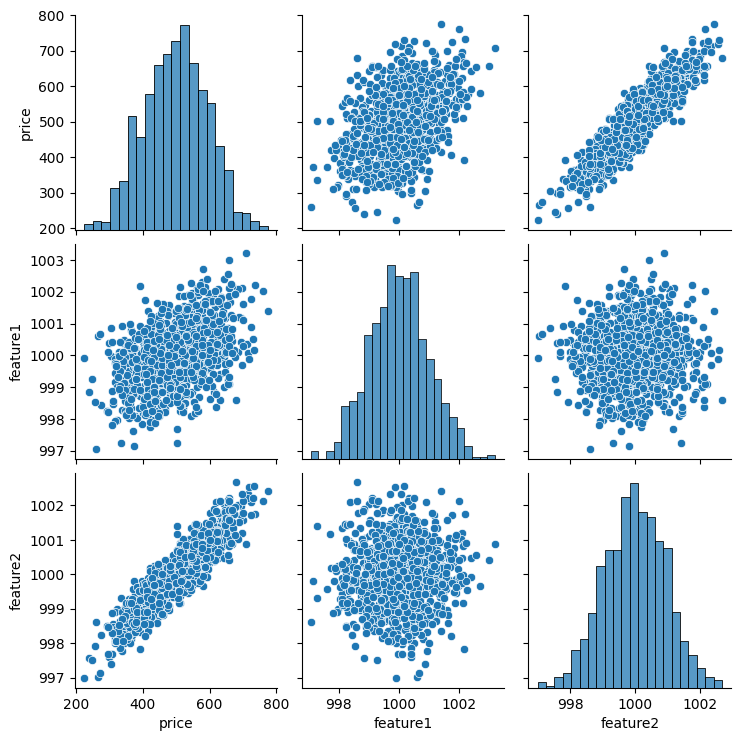

In [5]:
sns.pairplot(df)

### Test/Train Split

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X = df[['feature1', 'feature2']].values

In [8]:
y = df['price'].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
X_train.shape

(700, 2)

In [11]:
X_test.shape

(300, 2)

# Preprocessing the data

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
# help(MinMaxScaler)

## Normalizing/Scaling the Data

We scale the feature data.

[Why we don't need to scale the label](https://stats.stackexchange.com/questions/111467/is-it-necessary-to-scale-the-target-value-in-addition-to-scaling-features-for-re)

In [14]:
scaler = MinMaxScaler()

In [15]:
scaler.fit(X_train) # We fit, the data that can be used for transformation

MinMaxScaler()

In [16]:
# Transformation
X_train = scaler.transform(X_train)
X_train.shape

(700, 2)

In [17]:
X_test = scaler.transform(X_test)

# TensorFlow 2.0 Syntax


## Import Options

There are several ways you can import Keras from Tensorflow (this is hugely a personal style choice, please use any import methods you prefer). We will use the method shown in the **official TF documentation**.

# Model creation with Keras


There are two ways to create models through the TF 2 Keras API, either pass in a list of layers all at once, or add them one by one.

Let's show both methods (its up to you to choose which method you prefer).

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### Model - as a list of layers

In [23]:
model = Sequential([
    Dense(units=2),
    Dense(units=2),
    Dense(units=2)
])

### Model - adding in layers one by one

In [22]:
model = Sequential()

model.add(Dense(2))
model.add(Dense(2))
model.add(Dense(2))

Let's go ahead and build a simple model and then compile it by defining our solver

In [28]:
model = Sequential()

model.add(Dense(4, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(4, activation='relu'))

# Final output node for prediction
model.add(Dense(1))

model.compile(optimizer="rmsprop", loss="mse")

### Choosing an optimizer and loss

Keep in mind what kind of problem you are trying to solve:

    # For a multi-class classification problem
    model.compile(optimizer='rmsprop',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    # For a mean squared error regression problem
    model.compile(optimizer='rmsprop',
                  loss='mse')

# Training

Below are some common definitions that are necessary to know and understand to correctly utilize Keras:

* Sample: one element of a dataset.
    * Example: one image is a sample in a convolutional network
    * Example: one audio file is a sample for a speech recognition model
* Batch: a set of N samples. The samples in a batch are processed independently, in parallel. If training, a batch results in only one update to the model.A batch generally approximates the distribution of the input data better than a single input. The larger the batch, the better the approximation; however, it is also true that the batch will take longer to process and will still result in only one update. For inference (evaluate/predict), it is recommended to pick a batch size that is as large as you can afford without going out of memory (since larger batches will usually result in faster evaluation/prediction).
* Epoch: an arbitrary cutoff, generally defined as "one pass over the entire dataset", used to separate training into distinct phases, which is useful for logging and periodic evaluation.
* When using validation_data or validation_split with the fit method of Keras models, evaluation will be run at the end of every epoch.
* Within Keras, there is the ability to add callbacks specifically designed to be run at the end of an epoch. Examples of these are learning rate changes and model checkpointing (saving).

In [30]:
model.fit(x = X_train, y=y_train, epochs=250)

Epoch 1/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - loss: 253176.7656
Epoch 2/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step - loss: 260303.0781
Epoch 3/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - loss: 256065.8438
Epoch 4/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step - loss: 255396.4219
Epoch 5/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 345us/step - loss: 254860.0625
Epoch 6/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 381us/step - loss: 255956.8281
Epoch 7/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - loss: 261116.0156
Epoch 8/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step - loss: 258800.1406
Epoch 9/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - loss: 249165.0938
Epoch 10/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step - loss: 252516.8438
Epoch 11/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 408us/step - loss: 250046.4688
Epoch 12/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 399us/step - loss: 248825.7188
Epoch 13/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - loss: 246819.0625
Epoch 14/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 351u

## Evaluation

Let's evaluate our performance on our training set and our test set. We can compare these two performances to check for overfitting.

In [37]:
loss_df = pd.DataFrame(model.history.history)
loss_df

,loss
0,256556.828125
1,256301.718750
2,256059.125000
3,255779.500000
4,255451.640625
...,...
245,24.263109
246,24.384634
247,23.887377
248,24.489883


<Axes: >

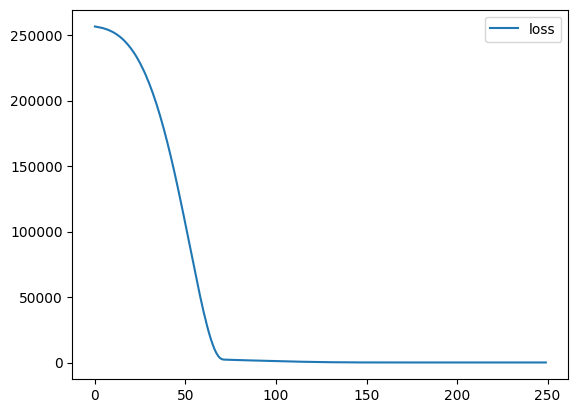

In [38]:
loss_df.plot()

### Compare final evaluation (MSE) on training set and test set.

These should hopefully be fairly close to each other.

In [47]:
model.metrics_variables

[<KerasVariable shape=(), dtype=float32, path=loss/total>,
 <KerasVariable shape=(), dtype=float32, path=loss/count>]

In [48]:
training_score = model.evaluate(X_train, y_train, verbose=0)
training_score

26.182579040527344

In [49]:
test_score = model.evaluate(X_test, y_test, verbose=0)
test_score

29.016019821166992

### Further Evaluations

In [51]:
test_pred = model.predict(X_test)
test_pred

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step


array([[406.80472],
       [625.8714 ],
       [594.3581 ],
       [574.3383 ],
       [367.93393],
       [581.3372 ],
       [516.927  ],
       [460.84488],
       [551.2723 ],
       [449.21793],
       [614.0749 ],
       [551.05084],
       [420.6627 ],
       [410.3859 ],
       [653.7325 ],
       [438.9491 ],
       [510.3973 ],
       [662.3545 ],
       [665.0422 ],
       [567.6734 ],
       [335.44962],
       [446.49374],
       [383.9363 ],
       [380.1732 ],
       [568.7103 ],
       [612.8481 ],
       [534.37384],
       [429.46494],
       [657.8643 ],
       [415.65033],
       [444.3116 ],
       [486.94223],
       [440.05753],
       [684.3746 ],
       [426.3805 ],
       [419.2255 ],
       [503.86093],
       [552.5384 ],
       [511.5989 ],
       [396.78497],
       [620.91644],
       [418.20157],
       [606.7198 ],
       [447.665  ],
       [503.8654 ],
       [583.94916],
       [671.54596],
       [492.25735],
       [319.79373],
       [487.23752],


In [61]:
y_test.shape, test_pred.shape

((300,), (300, 1))

In [62]:
# X_test
pred_df = pd.DataFrame({'Test Y': y_test, 'Model Predictions': test_pred.reshape(300,)})
pred_df

,Test Y,Model Predictions
0,402.296319,406.804718
1,624.156198,625.871399
2,582.455066,594.358093
3,578.588606,574.338318
4,371.224104,367.933929
...,...,...
295,525.704657,530.999512
296,502.909473,517.171936
297,612.727910,611.937439
298,417.569725,418.538544


<Axes: xlabel='Test Y', ylabel='Model Predictions'>

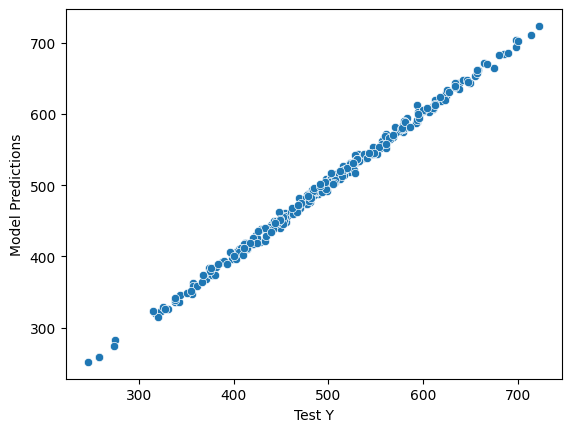

In [63]:
sns.scatterplot(x='Test Y',y='Model Predictions',data=pred_df)

/var/folders/1l/jh7lxvwd53g4g8kvvttg5mn00000gn/T/ipykernel_1242/749608862.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pred_df['Error'],bins=50)


<Axes: xlabel='Error', ylabel='Density'>

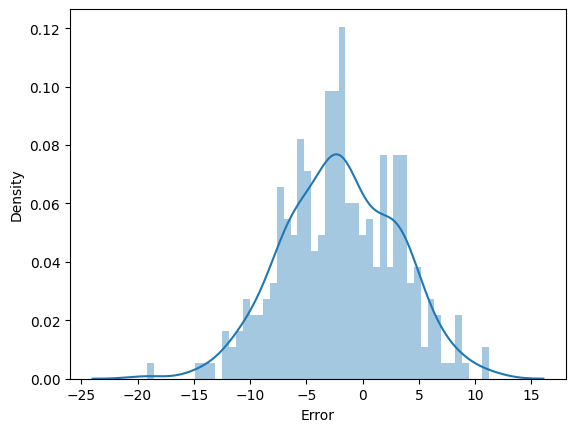

In [70]:
pred_df['Error'] = pred_df['Test Y'] - pred_df['Model Predictions']
sns.distplot(pred_df['Error'],bins=50)

<Axes: xlabel='Error', ylabel='Count'>

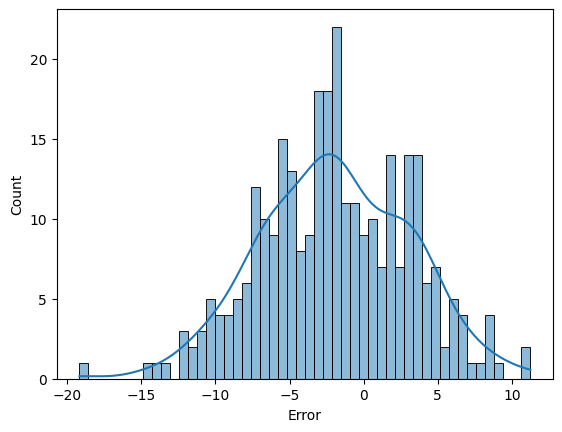

In [75]:
sns.histplot(pred_df['Error'],bins=50,kde='plasma')

In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [77]:
mean_absolute_error(pred_df['Test Y'], pred_df['Model Predictions'])

4.3780923025047125

In [78]:
mean_squared_error(pred_df['Test Y'],pred_df['Model Predictions'])

29.016019853425217

In [79]:
# Essentially the same thing, difference just due to precision
test_score

29.016019821166992

In [80]:
#RMSE
test_score**0.5

5.386652004832593